# Week 1 — Exercises for next week

From the end of `week1_visualization.ipynb`, Part 6:

1. **Family size and survival.** Did travelling alone help or hurt? Pick the chart type deliberately and
   justify your choice.
2. **Port of embarkation.** Is there a survival difference by `Port`? Check whether it is real or whether
   `Port` is just standing in for `Class`.
3. **Fix a bad chart.** Find a chart that breaks at least two of the lecture's rules, name the rules, and
   sketch the version you would draw instead.
4. **Redraw one of our charts badly**, on purpose, and write what a reader would wrongly conclude.

This notebook rebuilds `df` exactly as the lecture does, then works through all four.

> Run `python3 download_data.py` first, and run this notebook from the same folder as the lecture notebook
> (it expects `data/titanic.csv`).

## 0. Setup — same house style as the lecture

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

DATA = Path("data")
CHARTS = Path("charts")
CHARTS.mkdir(exist_ok=True)

# ---- House palette (same as the lecture) ---------------------------
BLUE, ORANGE, AQUA = "#2a78d6", "#eb6834", "#1baf7a"
YELLOW, MAGENTA = "#eda100", "#e87ba4"
GREEN, VIOLET, RED = "#008300", "#4a3aa7", "#e34948"
SERIES = [BLUE, ORANGE, AQUA, YELLOW, MAGENTA, GREEN, VIOLET, RED]

# Ink + surface colours. Text is NEVER the colour of the data.
INK, INK_SOFT, INK_MUTED = "#0b0b0b", "#52514e", "#8a8985"
GRID, SURFACE, QUIET = "#e6e5e1", "#fcfcfb", "#cfceca"

# ---- House style ---------------------------------------------------
plt.rcParams.update(
    {
        "figure.figsize": (8, 4.5),
        "figure.facecolor": SURFACE,
        "axes.facecolor": SURFACE,
        "axes.edgecolor": GRID,
        "axes.labelcolor": INK_SOFT,
        "axes.titlecolor": INK,
        "axes.titlesize": 13,
        "axes.titleweight": "bold",
        "axes.titlelocation": "left",
        "axes.titlepad": 14,
        "axes.labelsize": 10,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": True,
        "grid.color": GRID,
        "grid.linewidth": 0.8,
        "xtick.color": INK_SOFT,
        "ytick.color": INK_SOFT,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
        "legend.frameon": False,
        "legend.fontsize": 10,
        "lines.linewidth": 2,
        "font.size": 11,
        "savefig.dpi": 150,
        "savefig.bbox": "tight",
    }
)


def save(fig, name):
    # Save every chart to charts/ so it can be dropped into slides.
    fig.savefig(CHARTS / f"{name}.png", facecolor=SURFACE)


def footnote(ax, text, y=-0.2):
    # One-line note under a chart: exclusions, sample sizes, caveats.
    ax.text(0, y, text, transform=ax.transAxes, fontsize=9, color=INK_MUTED)


print("Ready. pandas", pd.__version__)

Ready. pandas 3.0.2


## 1. Rebuild `df`, exactly as Part 3 of the lecture does

In [2]:
titanic = pd.read_csv(DATA / "titanic.csv")

df = titanic.copy()
df = df.drop(columns=["Cabin", "Ticket", "PassengerId"])

df["Class"] = df["Pclass"].map({1: "1st class", 2: "2nd class", 3: "3rd class"})
df["Sex"] = df["Sex"].str.capitalize()
df["Outcome"] = df["Survived"].map({0: "Died", 1: "Survived"})
df["Port"] = df["Embarked"].map({"C": "Cherbourg", "Q": "Queenstown", "S": "Southampton"})

df["FamilySize"] = df["SibSp"] + df["Parch"] + 1
df["AgeGroup"] = pd.cut(
    df["Age"],
    bins=[0, 12, 19, 39, 59, 100],
    labels=["Child (0-12)", "Teen (13-19)", "Adult (20-39)", "Middle (40-59)", "Senior (60+)"],
)

print("Rows:", len(df))
df[["Class", "Sex", "Port", "FamilySize", "Outcome"]].head()

Rows: 891


,Class,Sex,Port,FamilySize,Outcome
0,3rd class,Male,Southampton,2,Died
1,1st class,Female,Cherbourg,2,Survived
2,3rd class,Female,Southampton,1,Survived
3,1st class,Female,Southampton,2,Survived
4,3rd class,Male,Southampton,1,Died


---
## Exercise 1 — Family size and survival

**Question:** *Did travelling alone help or hurt?*

`FamilySize` (`SibSp + Parch + 1`) is a genuine **ordered numeric scale** — 1 person, 2 people, 3 people,
and so on, with meaningful steps between them. Following the lecture's own rule (*"use a line when the
x-axis has a natural order"*), this is a **line chart**, not a bar chart: `FamilySize` is not a set of
unrelated categories like `Class`, it is a count that increases.

In [3]:
by_size = (
    df.groupby("FamilySize")
    .agg(passengers=("Survived", "size"), survival_rate=("Survived", "mean"))
    .reset_index()
)
by_size["survival_rate"] = (by_size["survival_rate"] * 100).round(1)
by_size

,FamilySize,passengers,survival_rate
0,1,537,30.4
1,2,161,55.3
2,3,102,57.8
3,4,29,72.4
4,5,15,20.0
5,6,22,13.6
6,7,12,33.3
7,8,6,0.0
8,11,7,0.0


Two family sizes (8 and 11) have only 6-7 passengers each, all of whom died — with that few people, a
single family's bad luck can swing the rate to 0%. Plotting those points at the same visual weight as the
537-passenger "alone" group would be exactly the mistake the lecture's messy chart made (*"a single
person and a group of 43 people are drawn at identical visual weight"*). I mark sample size directly on
the chart instead of hiding it.

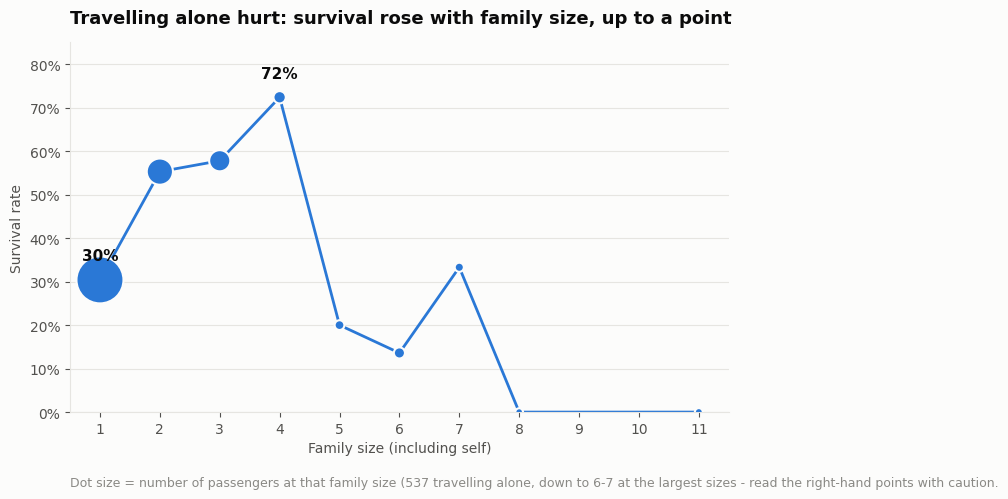

In [4]:
fig, ax = plt.subplots(figsize=(8.5, 4.8))

# Point AREA encodes sample size, so a reader can see which points to trust.
sizes = 18 + 2.1 * by_size["passengers"]
ax.plot(by_size["FamilySize"], by_size["survival_rate"], color=BLUE, linewidth=2, zorder=2)
ax.scatter(by_size["FamilySize"], by_size["survival_rate"], s=sizes, color=BLUE,
           edgecolor=SURFACE, linewidth=1.5, zorder=3)

for _, row in by_size.iterrows():
    if row["FamilySize"] in (1, 4):  # label only the two points that carry the message
        ax.annotate(f"{row['survival_rate']:.0f}%", (row["FamilySize"], row["survival_rate"]),
                    textcoords="offset points", xytext=(0, 14), ha="center",
                    fontsize=11, fontweight="bold", color=INK)

ax.set_title("Travelling alone hurt: survival rose with family size, up to a point")
ax.set_xlabel("Family size (including self)")
ax.set_ylabel("Survival rate")
ax.set_xticks(range(1, 12))
ax.set_ylim(0, 85)
ax.yaxis.set_major_formatter(lambda v, p: f"{v:.0f}%")
ax.xaxis.grid(False)
footnote(ax, "Dot size = number of passengers at that family size (537 travelling alone, "
             "down to 6-7 at the largest sizes - read the right-hand points with caution.")

save(fig, "ex1_family_size_line")
plt.show()

**Answer: travelling alone hurt.** Solo passengers (537 of them, by far the biggest group) survived at
just **30%**. Survival then **rises** with family size, peaking at **72% for families of 4** — but it is
not a straight climb: past a family of 4, survival **falls again**, down to 0% for the two largest,
sparsely-populated family sizes.

So the honest finding has two parts, and the chart is built to show both: *alone is worse than having a
small family*, but *a family that is too large is worse still* (likely large families found it harder to
stay together and reach a lifeboat). A single number like "average survival by family size" would have
hidden this rise-then-fall shape completely — the same lesson as Anscombe's quartet, showing up again.

---
## Exercise 2 — Port of embarkation

**Question:** *Is there a survival difference by `Port`? Is it real, or is `Port` standing in for `Class`?*

`Port` is an unordered category, so the first chart is a plain **bar chart**, sorted by value.

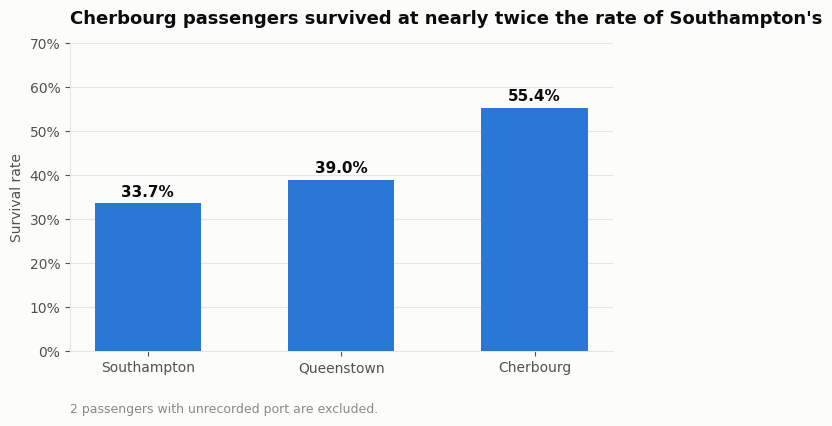

In [5]:
by_port = (
    df.dropna(subset=["Port"])
    .groupby("Port")
    .agg(passengers=("Survived", "size"), survival_rate=("Survived", "mean"))
    .reset_index()
    .sort_values("survival_rate")
)
by_port["survival_rate"] = (by_port["survival_rate"] * 100).round(1)

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(by_port["Port"], by_port["survival_rate"], color=BLUE, width=0.55, zorder=3)
for bar, v in zip(bars, by_port["survival_rate"]):
    ax.text(bar.get_x() + bar.get_width() / 2, v + 1.5, f"{v}%", ha="center",
            fontsize=11, fontweight="bold", color=INK)

ax.set_title("Cherbourg passengers survived at nearly twice the rate of Southampton's")
ax.set_ylabel("Survival rate")
ax.set_ylim(0, 70)
ax.yaxis.set_major_formatter(lambda v, p: f"{v:.0f}%")
ax.xaxis.grid(False)
ax.set_axisbelow(True)
footnote(ax, "2 passengers with unrecorded port are excluded.")

save(fig, "ex2_port_bar")
plt.show()

On its own, that looks like a real port effect: 55% survived from Cherbourg against 34% from Southampton.
But the lecture's warning applies directly here — before trusting a difference between groups, check
whether a **third variable is doing the real work.** `Class` is the obvious suspect, since we already
know class was the single biggest driver of survival. Let's see how the two overlap.

In [6]:
mix = pd.crosstab(df.dropna(subset=["Port"])["Port"], df["Class"], normalize="index").mul(100).round(1)
mix = mix.loc[by_port["Port"]]  # keep the same sorted order as the chart above
mix

Class,1st class,2nd class,3rd class
Port,,,
Southampton,19.7,25.5,54.8
Queenstown,2.6,3.9,93.5
Cherbourg,50.6,10.1,39.3


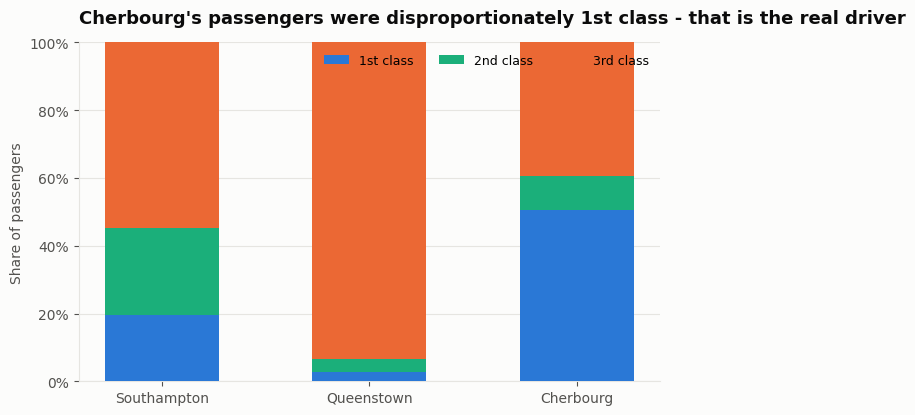

In [7]:
fig, ax = plt.subplots(figsize=(7.5, 4.4))
bottom = np.zeros(len(mix))
for cls, colour in zip(["1st class", "2nd class", "3rd class"], [BLUE, AQUA, ORANGE]):
    ax.bar(mix.index, mix[cls], bottom=bottom, color=colour, width=0.55, label=cls, zorder=3)
    bottom += mix[cls].values

ax.set_title("Cherbourg's passengers were disproportionately 1st class - that is the real driver")
ax.set_ylabel("Share of passengers")
ax.set_ylim(0, 100)
ax.yaxis.set_major_formatter(lambda v, p: f"{v:.0f}%")
ax.xaxis.grid(False)
ax.legend(loc="upper right", ncol=3, fontsize=9)

save(fig, "ex2_port_class_mix")
plt.show()

**The composition confirms the suspicion:** roughly half of Cherbourg's passengers travelled 1st class,
against about a fifth from Southampton. So Cherbourg's high survival rate is largely a reflection of who
boarded there, not of the port itself. To isolate the real port effect I need to compare survival **within
the same class**.

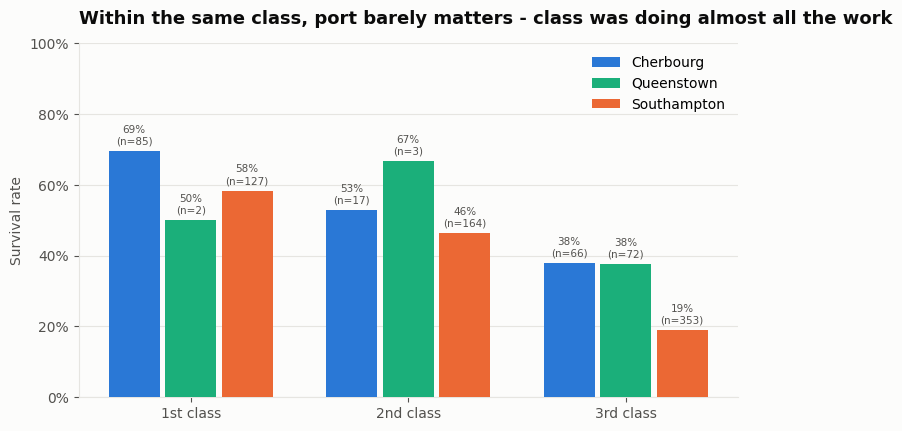

In [8]:
within = (
    df.dropna(subset=["Port"])
    .groupby(["Class", "Port"])["Survived"]
    .agg(passengers="size", survival_rate="mean")
    .reset_index()
)
within["survival_rate"] = (within["survival_rate"] * 100).round(1)

fig, ax = plt.subplots(figsize=(8.5, 4.6))
classes = ["1st class", "2nd class", "3rd class"]
ports = ["Cherbourg", "Queenstown", "Southampton"]
port_colour = {"Cherbourg": BLUE, "Queenstown": AQUA, "Southampton": ORANGE}
x = np.arange(len(classes))
width = 0.26

for i, port in enumerate(ports):
    vals = [within.query("Class == @c and Port == @port")["survival_rate"]
            .pipe(lambda s: s.iloc[0] if len(s) else np.nan) for c in classes]
    ns = [within.query("Class == @c and Port == @port")["passengers"]
          .pipe(lambda s: s.iloc[0] if len(s) else 0) for c in classes]
    bars = ax.bar(x + (i - 1) * width, vals, width=width * 0.9, color=port_colour[port],
                  label=port, zorder=3)
    for bar, v, n in zip(bars, vals, ns):
        if not np.isnan(v):
            ax.text(bar.get_x() + bar.get_width() / 2, v + 2, f"{v:.0f}%\n(n={n})", ha="center",
                    fontsize=7.5, color=INK_SOFT)

ax.set_xticks(x)
ax.set_xticklabels(classes)
ax.set_title("Within the same class, port barely matters - class was doing almost all the work")
ax.set_ylabel("Survival rate")
ax.set_ylim(0, 100)
ax.yaxis.set_major_formatter(lambda v, p: f"{v:.0f}%")
ax.xaxis.grid(False)
ax.legend(loc="upper right")

save(fig, "ex2_port_within_class")
plt.show()

**Answer: mostly not real.** Within 1st class, Cherbourg (69%) and Southampton (58%) are much closer
together than the raw 55%-vs-34% headline suggested — an 11-point gap instead of a 22-point one. Within
3rd class a real gap remains (38% vs 19%, and Southampton's sample of 353 makes that number fairly solid),
but even that is a smaller and more believable story than "Cherbourg is a lucky port": it is one class,
compared fairly, still showing a difference. **Queenstown's 1st and 2nd class numbers should be
ignored** — they are based on only 2 and 3 passengers, far too few to say anything.

So `Port` looked like a strong, independent effect, but roughly half of the 1st-class gap and some of
the 3rd-class gap survive controlling for `Class` — the effect shrinks, it does not fully disappear. This is exactly the preview the lecture promised: *"charts can show correlation that is really
something else in disguise."* Port is not nothing — some of the Southampton 3rd-class gap does persist —
but the headline "Cherbourg passengers survived at nearly twice the rate" is mostly a **class** story
wearing a **port** costume.

---
## Exercise 3 — Fix a bad chart from the media

I don't have a way to browse a newspaper or social feed from here, so I picked a well-documented
real case instead of an invented one: a bar chart aired on Fox News in 2012, comparing the top US income
tax rate under two scenarios (35% versus 39.6% if a tax cut expired). It was widely
criticised, including by Media Matters' collection of misleading Fox graphics, for starting its y-axis at
34% instead of 0.

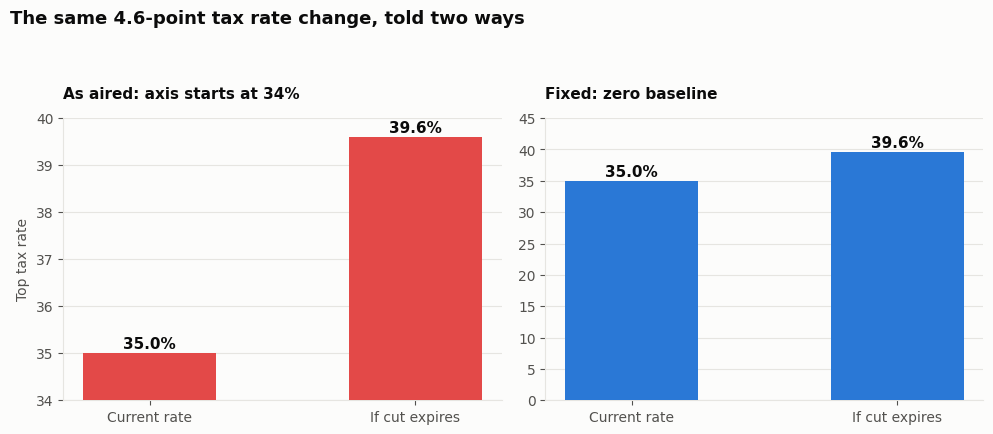

In [9]:
scenario = pd.DataFrame({"label": ["Current rate", "If cut expires"], "rate": [35.0, 39.6]})

fig, axes = plt.subplots(1, 2, figsize=(10, 4.4))

# LEFT: reconstruction of the style of chart that aired - axis starts at 34, not 0.
left = axes[0]
bars = left.bar(scenario["label"], scenario["rate"], color=RED, width=0.5, zorder=3)
for bar, v in zip(bars, scenario["rate"]):
    left.text(bar.get_x() + bar.get_width() / 2, v + 0.1, f"{v}%", ha="center",
              fontsize=11, fontweight="bold", color=INK)
left.set_ylim(34, 40)
left.set_title("As aired: axis starts at 34%", fontsize=11)
left.set_ylabel("Top tax rate")
left.xaxis.grid(False)

# RIGHT: the same numbers, honest zero baseline.
right = axes[1]
bars = right.bar(scenario["label"], scenario["rate"], color=BLUE, width=0.5, zorder=3)
for bar, v in zip(bars, scenario["rate"]):
    right.text(bar.get_x() + bar.get_width() / 2, v + 0.8, f"{v}%", ha="center",
               fontsize=11, fontweight="bold", color=INK)
right.set_ylim(0, 45)
right.set_title("Fixed: zero baseline", fontsize=11)
right.xaxis.grid(False)

for ax in axes:
    ax.set_axisbelow(True)
fig.suptitle("The same 4.6-point tax rate change, told two ways", x=0.01, ha="left",
             fontsize=13, fontweight="bold", color=INK)
fig.tight_layout(rect=[0, 0, 1, 0.92])
save(fig, "ex3_tax_chart_fixed")
plt.show()

**Rules it broke:**

1. **Bars did not start at zero.** With the axis starting at 34%, the second bar is drawn roughly **five
   times taller** than the first, even though the true change is 35% to 39.6% — a rise of about 13%
   *relative to the current rate*, not 500%. This is precisely the lecture's rule: *"the y-axis starts at
   zero — for bars this is compulsory."*
2. **The title (in the original) stated a subject, not a finding**, and let the geometry do the arguing
   instead of a sentence a reader could check.

**The version I would draw instead** is the right-hand panel above: same two numbers, zero baseline, each
bar labelled directly with its value. The change is still visible — bars **should** look different when
they are different — it is simply no longer exaggerated by a factor of five. A reader looking at the fixed
version can accurately conclude "a modest increase"; a reader looking at the original would reasonably, but
wrongly, conclude "the tax rate is about to increase dramatically."

*(Note: line charts are a genuine exception to the zero-baseline rule — a temperature line from 36.5°C to
38°C, for instance, should usually be zoomed in, because the reader already knows the meaningful range.
The rule that matters is specifically about **bars**, because a bar's length is the value.)*

---
## Exercise 4 — Redraw one of our own charts badly, on purpose

I'll take the lecture's cleanest chart — survival rate by class — and deliberately break three rules at
once: **truncate the y-axis**, **use a rainbow palette on a single series**, and **add a second, unrelated
y-axis**.

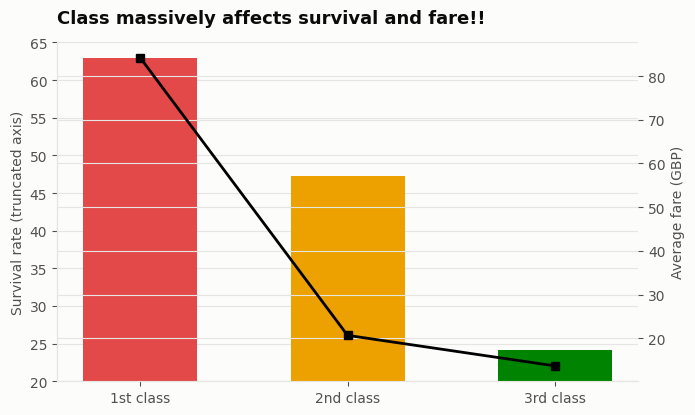

In [10]:
by_class = (
    df.groupby("Class")
    .agg(passengers=("Survived", "size"), survival_rate=("Survived", "mean"), fare=("Fare", "mean"))
    .reset_index()
)
by_class["survival_rate"] = (by_class["survival_rate"] * 100).round(1)

# =====================================================================
#  DELIBERATELY BAD - do not copy. Three violations at once.
# =====================================================================
fig, ax = plt.subplots(figsize=(7.5, 4.4))

rainbow = [RED, YELLOW, GREEN]  # a rainbow on a SINGLE series - colour means nothing here
bars = ax.bar(by_class["Class"], by_class["survival_rate"], color=rainbow, width=0.55, zorder=3)
ax.set_ylim(20, 65)  # truncated - not compulsory zero baseline
ax.set_ylabel("Survival rate (truncated axis)")

ax2 = ax.twinx()  # a second, unrelated y-axis
ax2.plot(by_class["Class"], by_class["fare"], color="black", marker="s", linewidth=2)
ax2.set_ylabel("Average fare (GBP)")

ax.set_title("Class massively affects survival and fare!!")
ax.xaxis.grid(False)

save(fig, "ex4_redrawn_badly")
plt.show()

**What a reader would wrongly conclude, and why:**

- **The truncated axis (20-65 instead of 0-100)** makes the gap between 1st class (63%) and 3rd class
  (24%) look even more extreme than it already is — the bars visually suggest 3rd class survival was
  "almost nothing" rather than "roughly 1 in 4."
- **The rainbow colours (red, yellow, green)** are applied to a single series with no grouping meaning,
  and red/green together is close to unreadable for colour-blind viewers. A reader would likely
  (wrongly) assume the colours encode something — a rating, a severity level — because that's the
  cultural association of red and green, when here they encode nothing at all.
- **The second y-axis (average fare, on a black line)** invites the reader to compare the line's
  position to the bars directly — for example, to conclude that "1st class survival and 1st class fare
  rose together at the same rate" — when in fact the two axes have completely different, arbitrarily
  chosen scales, so any apparent relationship between the line's slope and the bars' heights is an
  artifact of where I happened to set the two axis ranges, not a real property of the data.
- **The title ("Class massively affects survival and fare!!")** editorialises with punctuation instead of
  stating a checkable finding, and packs two separate claims into one sentence — exactly the "and" problem
  Part 5 warns about.

Compare this to the lecture's actual chart for the same data (`02_bar_class`, Part 4.1): zero baseline,
one colour, one y-axis, a title that states the finding. Same numbers, and a completely different, honest
reading experience.